In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                    📦 INSTALLATION (Run Once)                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Run this cell once to install all required packages

%pip install pandas==2.3.3 numpy matplotlib statsmodels scipy openpyxl --quiet

# DynaTMT (Current version: 2.9.3)
%pip install --upgrade "git+https://github.com/science64/DynaTMT.git"

# PBLMM - Peptide Based Linear Mixed Model (Current version: 2.1.3)
%pip install --upgrade "git+https://github.com/science64/PBLMM.git"

print("✅ All packages installed successfully!")

# 🧬 mePROD and mePRODmt Analysis Pipeline - Complete Template

This notebook provides a comprehensive workflow for analyzing **mePROD (Multiplexed enhanced protein dynamic mass spectrometry)** data using TMT multiplexing.

## 📋 Workflow Overview

| Step | MS2 Workflow | MS3 Workflow |
|------|-------------|--------------|
| 1 | Load PSMs data | Load PSMs data |
| 2 | Remove booster channel | Remove booster + baseline |
| 3 | Filter PSMs | Filter PSMs |
| 4 | **IT Adjustment** ✓ | Skip IT Adjustment |
| 5 | Normalization | Normalization |
| 6 | Extract Heavy/Light | Extract Heavy/Light |
| 7 | **Baseline Correction** ✓ | PSMs to Peptide (direct) |
| 8 | Statistical Analysis | Statistical Analysis |
| 9 | Export Results | Export Results |

### 🔑 Key Differences
- **MS2**: Requires IT adjustment and baseline correction (higher noise, needs correction)
- **MS3**: Cleaner signal, no IT adjustment needed, skip baseline correction

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                         📚 IMPORT LIBRARIES                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

from datetime import date
import numpy as np
import matplotlib.pyplot as plt
import warnings
import DynaTMT.DynaTMT as mePROD # should be ==> v2.9.3
import pandas as pd              # should be ==> v2.3.3
import PBLMM                     # should be ==> v2.1.3

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-whitegrid')

# Check versions
print("╔════════════════════════════════════════╗")
print("║       Package Versions Loaded          ║")
print("╠════════════════════════════════════════╣")
print(f"║  NumPy:          v{np.__version__:<20} ║")
print(f"║  DynaTMT:        {mePROD.__version__:<20}  ║")
print(f"║  Pandas:         v{pd.__version__:<20} ║")
print(f"║  PBLMM:          v{PBLMM.__version__:<20} ║")
print("╚════════════════════════════════════════╝")

╔════════════════════════════════════════╗
║       Package Versions Loaded          ║
╠════════════════════════════════════════╣
║  NumPy:          v1.26.4               ║
║  DynaTMT:        v2.9.3                ║
║  Pandas:         v2.3.3                ║
║  PBLMM:          v2.1.3                ║
╚════════════════════════════════════════╝


## ⚙️ Configuration Section

**Important:** Configure all parameters in the cell below before running the analysis!

In [2]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                      🎯 CONFIGURATION PARAMETERS                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ═══════════════════════════════════════════════════════════════════════════════
# 🔹 WORKFLOW TYPE - Choose your acquisition method
# ═══════════════════════════════════════════════════════════════════════════════
WORKFLOW_TYPE = "MS2"  # Options: "MS2" or "MS3"
                       # MS2: Uses IT adjustment + baseline correction
                       # MS3: Skips IT adjustment, direct PSM to peptide conversion

# ═══════════════════════════════════════════════════════════════════════════════
# 🔹 FILE PATHS
# ═══════════════════════════════════════════════════════════════════════════════
wd = "Example data/MS2_data"  # Working directory with your data
dataName = "20200724_SB_CCCP_ISRIB_Import_PSMs.txt"  # Your PSM file name
nameOfStudy = "CCCP_ISRIB_Import"  # Name for output files

# ═══════════════════════════════════════════════════════════════════════════════
# 🔹 TMT CHANNEL CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════
# Define channels to remove (booster, baseline, empty channels)
# Set to None if no channel needs to be removed
BASELINE_CHANNEL = "Abundance: 126"  # Baseline channel (MS2: keep for correction, MS3: remove)
BOOSTER_CHANNEL = "Abundance: 131C"  # Booster channel name (set None if no booster)

# ═══════════════════════════════════════════════════════════════════════════════
# 🔹 EXPERIMENTAL CONDITIONS
# ═══════════════════════════════════════════════════════════════════════════════
# Define conditions for each TMT channel (in order after removing booster)
# Example for TMT10: 126, 127N, 127C, 128N, 128C, 129N, 129C, 130N, 130C, 131N
conditions = ['Light', 'DMSO', 'DMSO', 'DMSO', 'CCCP', 'CCCP', 'CCCP', 'CCCP_ISRIB', 'CCCP_ISRIB', 'CCCP_ISRIB']

# Define comparison pairs [Treatment, Control] - Result: log2(Treatment/Control)
pairs = [
    ['CCCP', 'DMSO'],           # Compare CCCP vs DMSO
    ['CCCP_ISRIB', 'DMSO'],     # Compare CCCP+ISRIB vs DMSO  
    ['CCCP_ISRIB', 'CCCP']      # Compare CCCP+ISRIB vs CCCP alone
]

# ═══════════════════════════════════════════════════════════════════════════════
# 🔹 NORMALIZATION METHOD
# ═══════════════════════════════════════════════════════════════════════════════
NORMALIZATION_METHOD = "sum"  # Options: "sum", "median", "TMM"
                              # sum: Total intensity normalization (recommended)
                              # median: Median-based normalization
                              # TMM: Trimmed Mean of M-values (Robinson & Oshlack)

# ═══════════════════════════════════════════════════════════════════════════════
# 🔹 BASELINE CORRECTION PARAMETERS (MS2 only)
# ═══════════════════════════════════════════════════════════════════════════════
BASELINE_THRESHOLD = 15       # Signal-to-noise threshold (10-20 recommended)
BASELINE_INDEX = 0            # Column index of baseline channel (usually 0 = first channel)
RANDOM_REPLACEMENT = True     # Replace negative values with random (0-1) instead of 0

# ═══════════════════════════════════════════════════════════════════════════════
# 🔹 PROTEIN ROLLUP METHOD (if not using PBLMM)
# ═══════════════════════════════════════════════════════════════════════════════
ROLLUP_METHOD = "sum"  # Options: "sum", "mean", "median"

# Print configuration summary
print("╔══════════════════════════════════════════════════════════════╗")
print("║                  CONFIGURATION SUMMARY                       ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  Workflow Type:       {WORKFLOW_TYPE:<37}  ║")
print(f"║  Working Directory:   {wd:<37}  ║")
print(f"║  Data File:           {dataName[:35]:<37}  ║")
print(f"║  Normalization:       {NORMALIZATION_METHOD:<37}  ║")
print(f"║  Conditions:          {len(conditions)} channels                            ║")
print(f"║  Comparisons:         {len(pairs)} pairs                                ║")
print("╚══════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════╗
║                  CONFIGURATION SUMMARY                       ║
╠══════════════════════════════════════════════════════════════╣
║  Workflow Type:       MS2                                    ║
║  Working Directory:   Example data/MS2_data                  ║
║  Data File:           20200724_SB_CCCP_ISRIB_Import_PSMs.    ║
║  Normalization:       sum                                    ║
║  Conditions:          10 channels                            ║
║  Comparisons:         3 pairs                                ║
╚══════════════════════════════════════════════════════════════╝


In [4]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                    📊 HELPER VISUALIZATION FUNCTIONS                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def get_abundance_channels(df):
    """Extract abundance channel columns from dataframe."""
    return [col for col in df.columns 
            if 'abundance' in col.lower() and 'normaliz' not in col.lower()]

def plot_abundance_distribution(df, title="TMT Channel Distribution", figsize=(12, 5)):
    """Create a comprehensive visualization of abundance distribution."""
    channels = get_abundance_channels(df)
    abundance_df = df[channels].copy()
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Box plot
    ax1 = axes[0]
    bp = abundance_df.boxplot(ax=ax1, grid=False, vert=True, showfliers=False,
                              patch_artist=True, return_type='dict')
    
    # Color the boxes
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(channels)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax1.set_title(f"{title}\n(Box Plot)", fontsize=11, fontweight='bold')
    ax1.set_ylabel("Abundance Value", fontsize=10)
    ax1.set_xlabel("TMT Channels", fontsize=10)
    ax1.tick_params(axis='x', rotation=45)
    
    # Summary statistics bar plot
    ax2 = axes[1]
    channel_sums = abundance_df.sum()
    bars = ax2.bar(range(len(channels)), channel_sums.values, color=colors, alpha=0.7, edgecolor='black')
    ax2.set_title(f"{title}\n(Total Intensity per Channel)", fontsize=11, fontweight='bold')
    ax2.set_ylabel("Total Intensity", fontsize=10)
    ax2.set_xlabel("TMT Channels", fontsize=10)
    ax2.set_xticks(range(len(channels)))
    ax2.set_xticklabels([c.split(':')[-1].strip() if ':' in c else c.split()[-1] for c in channels], rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n📈 Data Statistics for: {title}")
    print(f"   └─ Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
    print(f"   └─ Total Intensity Range: {channel_sums.min():,.0f} - {channel_sums.max():,.0f}")
    print(f"   └─ CV between channels: {(channel_sums.std() / channel_sums.mean() * 100):.1f}%")
    return abundance_df

def compare_normalizations(df, process):
    """Compare different normalization methods visually."""
    print("🔄 Comparing normalization methods...")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    methods = {
        'Original': df,
        'Sum Normalization': process.total_intensity_normalisation(df.copy()),
        'Median Normalization': process.Median_normalisation(df.copy()),
        'TMM Normalization': process.TMM(df.copy())
    }
    
    for idx, (name, data) in enumerate(methods.items()):
        ax = axes[idx // 2, idx % 2]
        channels = get_abundance_channels(data)
        abundance_df = data[channels]
        
        bp = abundance_df.boxplot(ax=ax, grid=False, vert=True, showfliers=False,
                                   patch_artist=True, return_type='dict')
        colors = plt.cm.Set2(np.linspace(0, 1, len(channels)))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        channel_sums = abundance_df.sum()
        cv = (channel_sums.std() / channel_sums.mean() * 100)
        ax.set_title(f"{name}\nCV: {cv:.1f}%", fontsize=11, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylabel("Abundance")
    
    plt.suptitle("📊 Normalization Method Comparison", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return methods

def print_step_header(step_num, title, icon="🔹"):
    """Print a formatted step header."""
    print(f"\n{'═'*70}")
    print(f"{icon} STEP {step_num}: {title}")
    print(f"{'═'*70}")

print("✅ Helper functions loaded successfully!")

✅ Helper functions loaded successfully!


---
## 📂 Step 1: Data Loading & Initial Exploration

Load your PSM data and visualize the raw distribution to understand your starting point.


══════════════════════════════════════════════════════════════════════
📂 STEP 1: DATA LOADING
══════════════════════════════════════════════════════════════════════
✅ Data loaded successfully!
   └─ File: 20200724_SB_CCCP_ISRIB_Import_PSMs.txt
   └─ Shape: 203,381 PSMs × 48 columns

📋 Detected 11 abundance channels:
   0: Abundance: 126
   1: Abundance: 127N
   2: Abundance: 127C
   3: Abundance: 128N
   4: Abundance: 128C
   5: Abundance: 129N
   6: Abundance: 129C
   7: Abundance: 130N
   8: Abundance: 130C
   9: Abundance: 131N
   10: Abundance: 131C


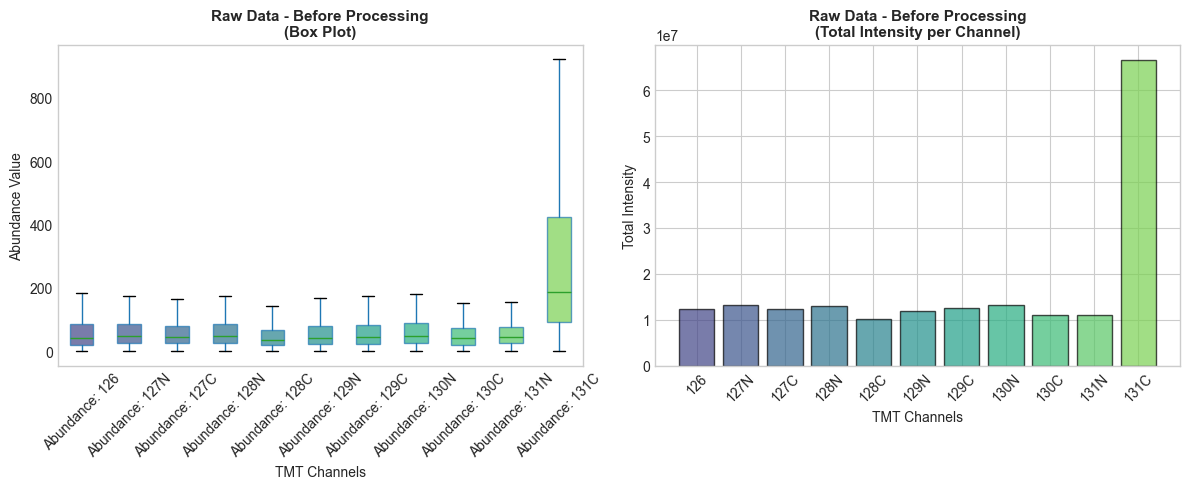


📈 Data Statistics for: Raw Data - Before Processing
   └─ Rows: 203,381 | Columns: 48
   └─ Total Intensity Range: 10,137,686 - 66,599,198
   └─ CV between channels: 96.7%


,Abundance: 126,Abundance: 127N,Abundance: 127C,Abundance: 128N,Abundance: 128C,Abundance: 129N,Abundance: 129C,Abundance: 130N,Abundance: 130C,Abundance: 131N,Abundance: 131C
0,69.1,42.0,23.5,23.4,22.8,44.2,41.6,15.5,81.2,40.3,405.0
1,23.8,37.8,25.1,44.9,34.1,50.9,50.9,53.7,18.2,45.5,786.3
2,NaN,NaN,NaN,2.2,NaN,4.4,2.7,NaN,4.1,NaN,154.3
3,15.4,7.4,4.9,3.3,5.1,7.3,10.9,4.6,16.3,7.5,24.1
4,7.8,4.7,4.3,3.1,3.4,3.4,4.0,4.1,NaN,NaN,496.6
...,...,...,...,...,...,...,...,...,...,...,...
203376,7.5,8.8,8.0,6.8,5.4,11.1,9.9,8.9,6.4,8.9,7.0
203377,2.5,2.5,4.3,3.4,3.4,6.3,6.0,5.0,4.7,4.5,2.9
203378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0
203379,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.9,2.9,3.0


In [5]:
print_step_header(1, "DATA LOADING", "📂")

# Load the PSM data
psms = pd.read_csv(f'{wd}/{dataName}', sep='\t', header=0)

# For Excel files, use:
# psms = pd.read_excel(f'{wd}/{dataName}', header=0)

print(f"✅ Data loaded successfully!")
print(f"   └─ File: {dataName}")
print(f"   └─ Shape: {psms.shape[0]:,} PSMs × {psms.shape[1]} columns")

# Display available abundance channels
channels = get_abundance_channels(psms)
print(f"\n📋 Detected {len(channels)} abundance channels:")
for i, ch in enumerate(channels):
    print(f"   {i}: {ch}")

# Show raw data distribution
plot_abundance_distribution(psms, "Raw Data - Before Processing")

---
## 🧹 Step 2: Channel Removal (Booster/Baseline)

Remove channels that shouldn't be included in the analysis:
- **Booster channel**: High-intensity spike-in for detection (always remove)
- **Baseline channel**: 
  - **MS2**: Keep for baseline correction (remove later)
  - **MS3**: Remove now (not needed for correction)


══════════════════════════════════════════════════════════════════════
🧹 STEP 2: CHANNEL REMOVAL
══════════════════════════════════════════════════════════════════════
✅ Removed booster channel: Abundance: 131C
ℹ️ Keeping baseline channel for MS2 baseline correction: Abundance: 126


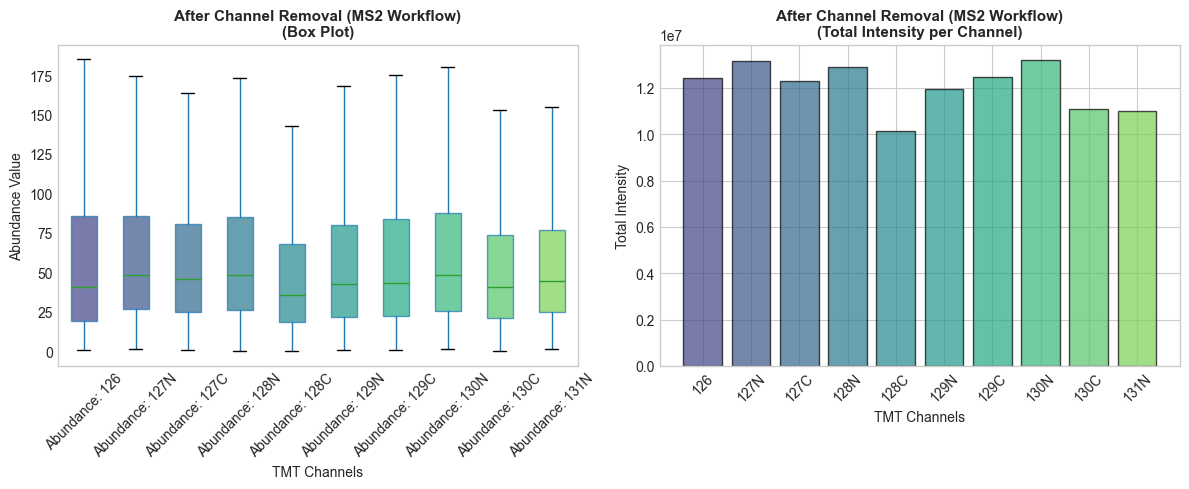


📈 Data Statistics for: After Channel Removal (MS2 Workflow)
   └─ Rows: 203,381 | Columns: 47
   └─ Total Intensity Range: 10,137,686 - 13,214,166
   └─ CV between channels: 8.5%


,Abundance: 126,Abundance: 127N,Abundance: 127C,Abundance: 128N,Abundance: 128C,Abundance: 129N,Abundance: 129C,Abundance: 130N,Abundance: 130C,Abundance: 131N
0,69.1,42.0,23.5,23.4,22.8,44.2,41.6,15.5,81.2,40.3
1,23.8,37.8,25.1,44.9,34.1,50.9,50.9,53.7,18.2,45.5
2,NaN,NaN,NaN,2.2,NaN,4.4,2.7,NaN,4.1,NaN
3,15.4,7.4,4.9,3.3,5.1,7.3,10.9,4.6,16.3,7.5
4,7.8,4.7,4.3,3.1,3.4,3.4,4.0,4.1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
203376,7.5,8.8,8.0,6.8,5.4,11.1,9.9,8.9,6.4,8.9
203377,2.5,2.5,4.3,3.4,3.4,6.3,6.0,5.0,4.7,4.5
203378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203379,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.9,2.9


In [6]:
print_step_header(2, "CHANNEL REMOVAL", "🧹")

# Start with original data
working_data = psms.copy()

# Remove booster channel if specified
if BOOSTER_CHANNEL is not None and BOOSTER_CHANNEL in working_data.columns:
    working_data = working_data.drop(BOOSTER_CHANNEL, axis=1)
    print(f"✅ Removed booster channel: {BOOSTER_CHANNEL}")
else:
    print(f"ℹ️ No booster channel removed (not found or not specified)")

# For MS3: Also remove baseline channel now
if WORKFLOW_TYPE == "MS3":
    if BASELINE_CHANNEL is not None and BASELINE_CHANNEL in working_data.columns:
        working_data = working_data.drop(BASELINE_CHANNEL, axis=1)
        print(f"✅ Removed baseline channel (MS3 workflow): {BASELINE_CHANNEL}")
else:
    print(f"ℹ️ Keeping baseline channel for MS2 baseline correction: {BASELINE_CHANNEL}")

# Show updated distribution
plot_abundance_distribution(working_data, f"After Channel Removal ({WORKFLOW_TYPE} Workflow)")

---
## 🔍 Step 3: Data Filtering

Apply quality filters to remove:
- ❌ Shared peptides (mapped to multiple proteins)
- ❌ Contaminant proteins  
- ❌ Rows with missing values in abundance channels
- ❌ PSMs with high isolation interference (>50%)


══════════════════════════════════════════════════════════════════════
🔍 STEP 3: DATA FILTERING
══════════════════════════════════════════════════════════════════════
Calling function: filter_PSMs

📊 Filtering Summary:
   └─ Before: 203,381 PSMs
   └─ After:  164,518 PSMs
   └─ Removed: 38,863 PSMs (19.1%)


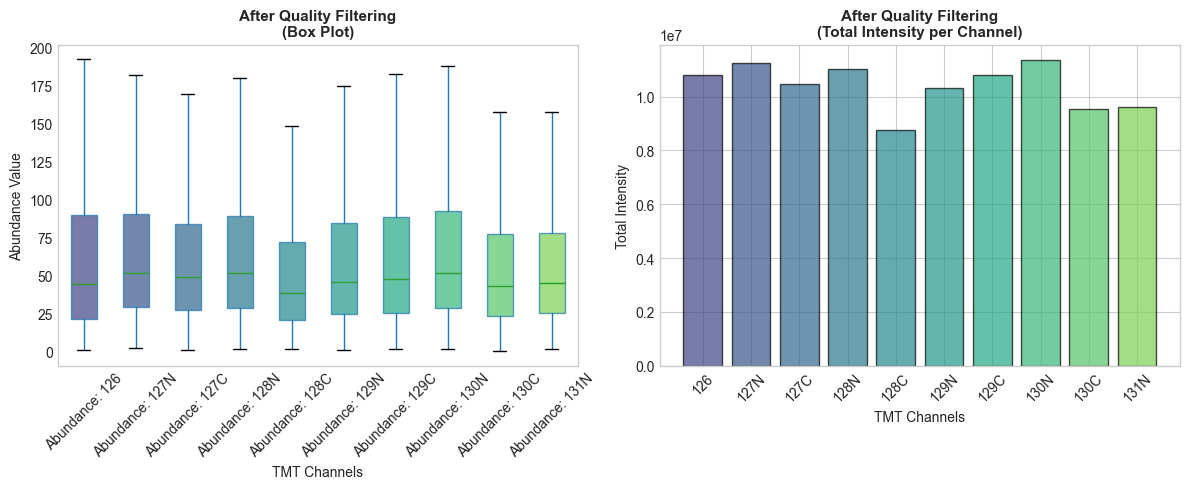


📈 Data Statistics for: After Quality Filtering
   └─ Rows: 164,518 | Columns: 47
   └─ Total Intensity Range: 8,746,182 - 11,365,140
   └─ CV between channels: 8.2%


,Abundance: 126,Abundance: 127N,Abundance: 127C,Abundance: 128N,Abundance: 128C,Abundance: 129N,Abundance: 129C,Abundance: 130N,Abundance: 130C,Abundance: 131N
0,69.1,42.0,23.5,23.4,22.8,44.2,41.6,15.5,81.2,40.3
1,23.8,37.8,25.1,44.9,34.1,50.9,50.9,53.7,18.2,45.5
3,15.4,7.4,4.9,3.3,5.1,7.3,10.9,4.6,16.3,7.5
5,10.2,12.7,13.4,15.2,9.5,10.9,7.9,11.4,14.6,11.9
6,16.6,12.2,11.9,12.5,9.7,21.3,14.3,11.2,17.4,99.1
...,...,...,...,...,...,...,...,...,...,...
203371,6.4,7.9,5.5,6.7,3.4,5.5,6.0,5.2,7.5,4.3
203372,6.8,7.7,8.0,7.2,4.1,8.0,4.6,5.0,5.4,3.8
203373,6.3,6.2,7.1,11.1,4.2,6.7,11.6,9.3,5.2,9.4
203376,7.5,8.8,8.0,6.8,5.4,11.1,9.9,8.9,6.4,8.9


In [7]:
print_step_header(3, "DATA FILTERING", "🔍")

# Initialize the processor
process = mePROD.PD_input(working_data)

# Filter PSMs
filter_data = process.filter_PSMs(working_data)

# Report filtering results
removed = working_data.shape[0] - filter_data.shape[0]
pct_removed = (removed / working_data.shape[0]) * 100

print(f"\n📊 Filtering Summary:")
print(f"   └─ Before: {working_data.shape[0]:,} PSMs")
print(f"   └─ After:  {filter_data.shape[0]:,} PSMs")
print(f"   └─ Removed: {removed:,} PSMs ({pct_removed:.1f}%)")

# Visualize
plot_abundance_distribution(filter_data, "After Quality Filtering")

---
## ⚡ Step 4: IT Adjustment (MS2 Only)

**Ion Injection Time (IT) Adjustment** compensates for different injection times across PSMs.
- Essential for **MS2** data where IT varies significantly
- **Skip for MS3** data (more consistent acquisition)


══════════════════════════════════════════════════════════════════════
⚡ STEP 4: IT ADJUSTMENT
══════════════════════════════════════════════════════════════════════
Calling function: IT_adjustment
✅ IT adjustment applied (MS2 workflow)


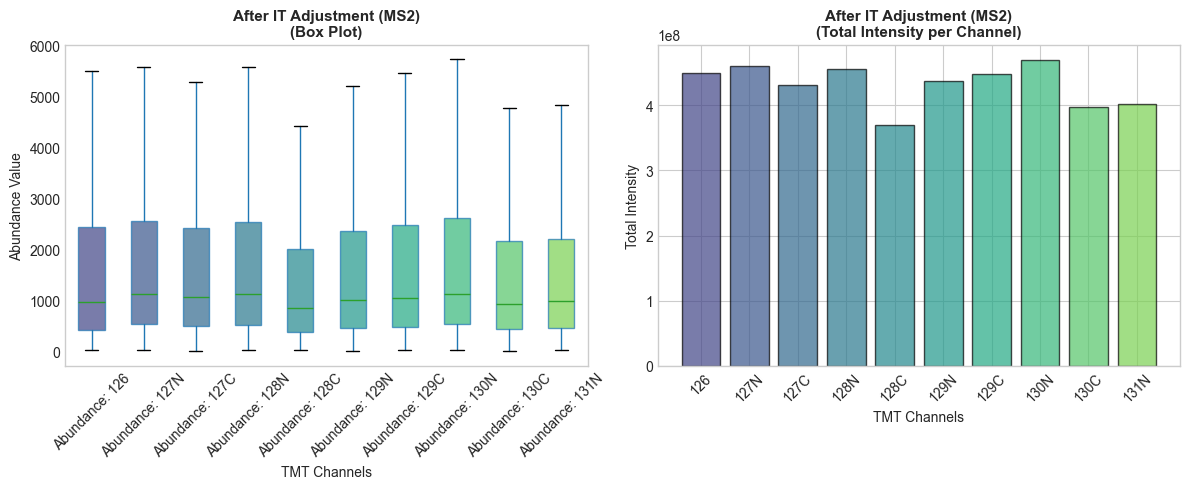


📈 Data Statistics for: After IT Adjustment (MS2)
   └─ Rows: 164,518 | Columns: 47
   └─ Total Intensity Range: 369,574,290 - 469,692,798
   └─ CV between channels: 7.5%


In [8]:
print_step_header(4, "IT ADJUSTMENT", "⚡")

if WORKFLOW_TYPE == "MS2":
    IT_adjusted = process.IT_adjustment(filter_data)
    print("✅ IT adjustment applied (MS2 workflow)")
    plot_abundance_distribution(IT_adjusted, "After IT Adjustment (MS2)")
    data_for_norm = IT_adjusted
else:
    print("⏭️ Skipping IT adjustment (MS3 workflow - not needed)")
    data_for_norm = filter_data
    print(f"   └─ Using filtered data directly for normalization")

---
## 📊 Step 5: Normalization

Choose from three normalization methods:

| Method | Description | Best For |
|--------|-------------|----------|
| **Sum** | Equalizes total intensity | Most experiments (recommended) |
| **Median** | Equalizes median intensity | Skewed distributions |
| **TMM** | Trimmed Mean of M-values | RNA-seq style normalization |

Run the comparison cell below to visualize all methods, then the normalization cell applies your chosen method.


══════════════════════════════════════════════════════════════════════
📊 STEP 5a: NORMALIZATION COMPARISON (Optional)
══════════════════════════════════════════════════════════════════════
🔄 Comparing normalization methods...
Calling function: total_intensity_normalisation
Calling function: Median_normalisation
Calling function: TMM
Normalization


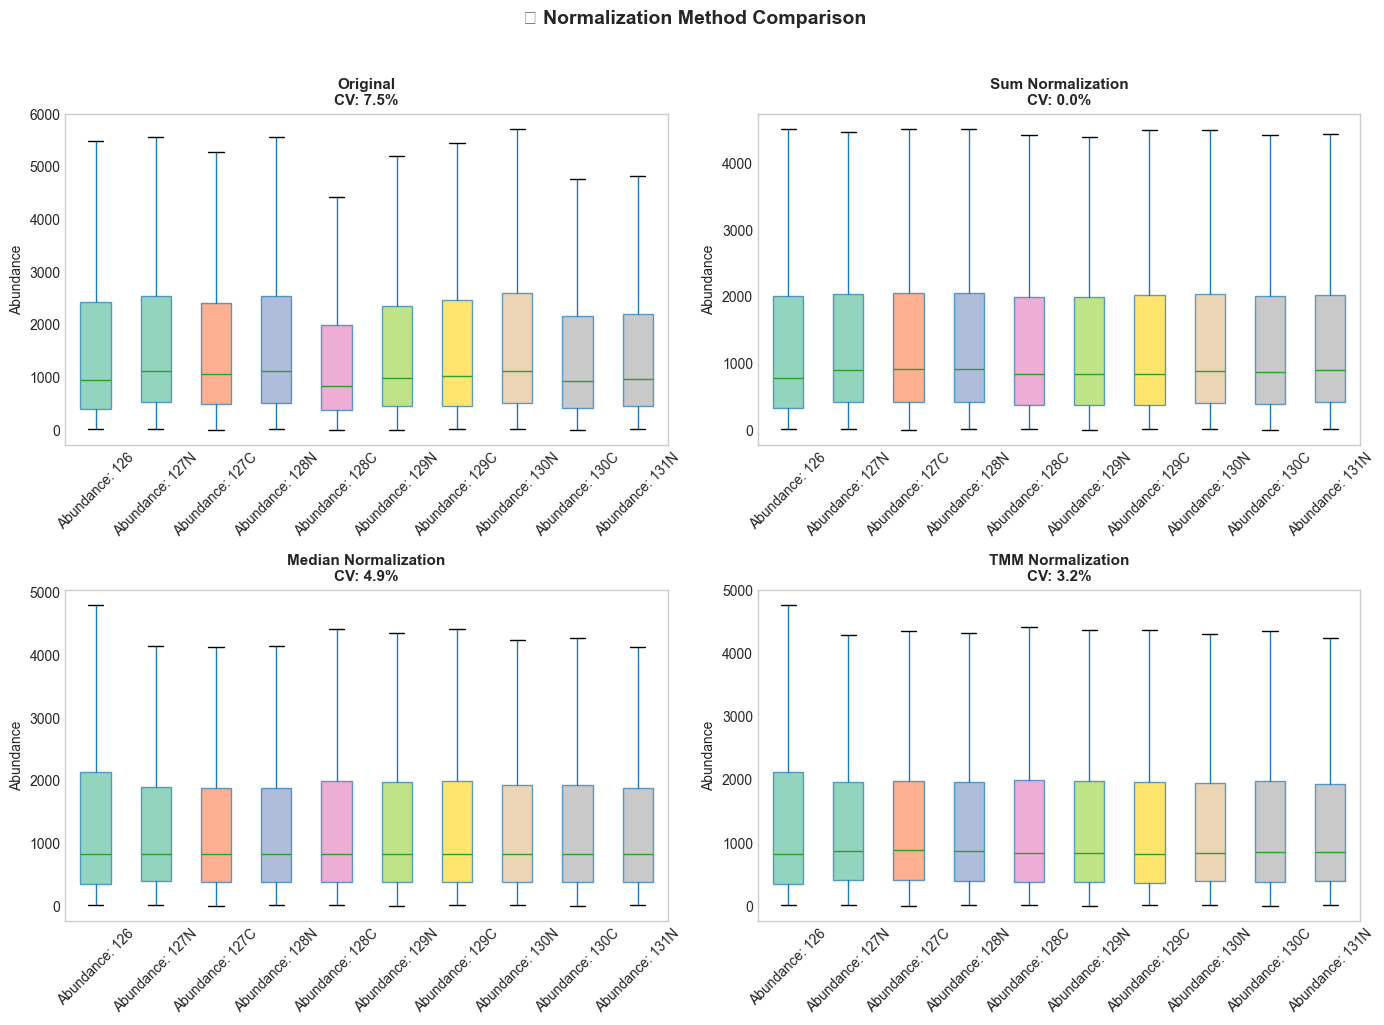


📋 Recommendation:
   └─ Look for the method with lowest CV (coefficient of variation)
   └─ Lower CV = more consistent intensities across channels


In [9]:
# Optional: Compare all normalization methods visually
print_step_header("5a", "NORMALIZATION COMPARISON (Optional)", "📊")

norm_methods = compare_normalizations(data_for_norm, process)

print("\n📋 Recommendation:")
print("   └─ Look for the method with lowest CV (coefficient of variation)")
print("   └─ Lower CV = more consistent intensities across channels")


══════════════════════════════════════════════════════════════════════
📊 STEP 5b: APPLYING SUM NORMALIZATION
══════════════════════════════════════════════════════════════════════
Calling function: total_intensity_normalisation
✅ Applied: Total Intensity (Sum) Normalization


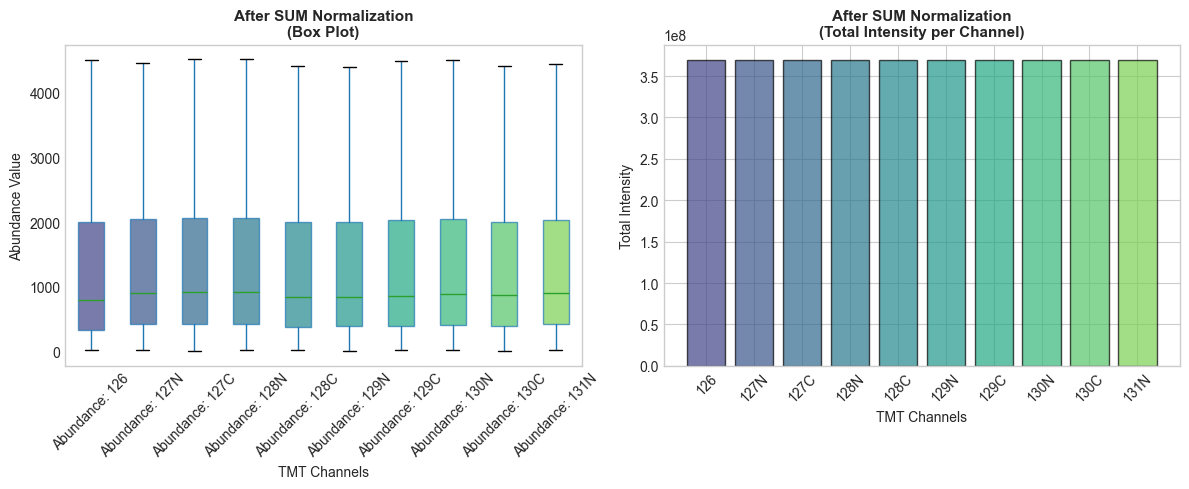


📈 Data Statistics for: After SUM Normalization
   └─ Rows: 164,518 | Columns: 47
   └─ Total Intensity Range: 369,574,290 - 369,574,290
   └─ CV between channels: 0.0%


,Abundance: 126,Abundance: 127N,Abundance: 127C,Abundance: 128N,Abundance: 128C,Abundance: 129N,Abundance: 129C,Abundance: 130N,Abundance: 130C,Abundance: 131N
0,661.012758,391.597125,233.919009,220.987146,265.116279,434.857450,398.531899,141.814650,876.818680,431.673950
1,227.671543,352.437412,249.845409,424.030892,396.511628,500.774756,487.626771,491.319143,196.528325,487.373815
3,387.664140,181.562034,128.350288,82.010264,156.053976,188.995133,274.789017,110.751686,463.174331,211.404960
5,97.573519,118.411512,133.383605,143.547206,110.465116,107.238602,75.682740,104.302388,157.654590,127.466998
6,158.796118,113.749641,118.452604,118.048689,112.790698,209.558002,136.995340,102.472521,187.889717,1061.510880
...,...,...,...,...,...,...,...,...,...,...
203371,71.144821,85.595083,63.619736,73.528800,45.942221,62.880915,66.796319,55.287158,94.112335,53.524272
203372,65.049012,71.792806,79.632003,67.996045,47.674419,78.707231,44.068431,45.746661,58.310602,40.703747
203373,60.265997,57.807195,70.673403,104.827236,48.837209,65.917306,111.129087,85.088790,56.150950,100.688217
203376,71.745234,82.048921,79.632003,64.218487,62.790698,109.206283,94.842928,81.429057,69.108861,95.332460


In [10]:
# Apply selected normalization method
print_step_header("5b", f"APPLYING {NORMALIZATION_METHOD.upper()} NORMALIZATION", "📊")

if NORMALIZATION_METHOD == "sum":
    normalized_data = process.total_intensity_normalisation(data_for_norm)
    print("✅ Applied: Total Intensity (Sum) Normalization")
elif NORMALIZATION_METHOD == "median":
    normalized_data = process.Median_normalisation(data_for_norm)
    print("✅ Applied: Median Normalization")
elif NORMALIZATION_METHOD == "TMM":
    normalized_data = process.TMM(data_for_norm)
    print("✅ Applied: TMM Normalization")
else:
    normalized_data = process.total_intensity_normalisation(data_for_norm)
    print("⚠️ Unknown method, defaulting to Sum Normalization")

plot_abundance_distribution(normalized_data, f"After {NORMALIZATION_METHOD.upper()} Normalization")

---
## 🏷️ Step 6: Heavy/Light Peptide Extraction

Separate peptides based on SILAC labeling:
- **Heavy peptides**: Newly synthesized proteins (contains Label/TMTK modifications)
- **Light peptides**: Pre-existing proteins (no SILAC label)

For mePROD analysis, we primarily use **heavy** peptides.


══════════════════════════════════════════════════════════════════════
🏷️ STEP 6: HEAVY/LIGHT EXTRACTION
══════════════════════════════════════════════════════════════════════
Calling function: extract_heavy
Extraction Done Extracted Heavy PSMs/Peptides: 65547
Calling function: extract_light
Extraction Done Extracted Light PSMs/Peptides: 98971

📊 Extraction Summary:
   └─ Heavy PSMs: 65,547 (39.8%)
   └─ Light PSMs: 98,971 (60.2%)


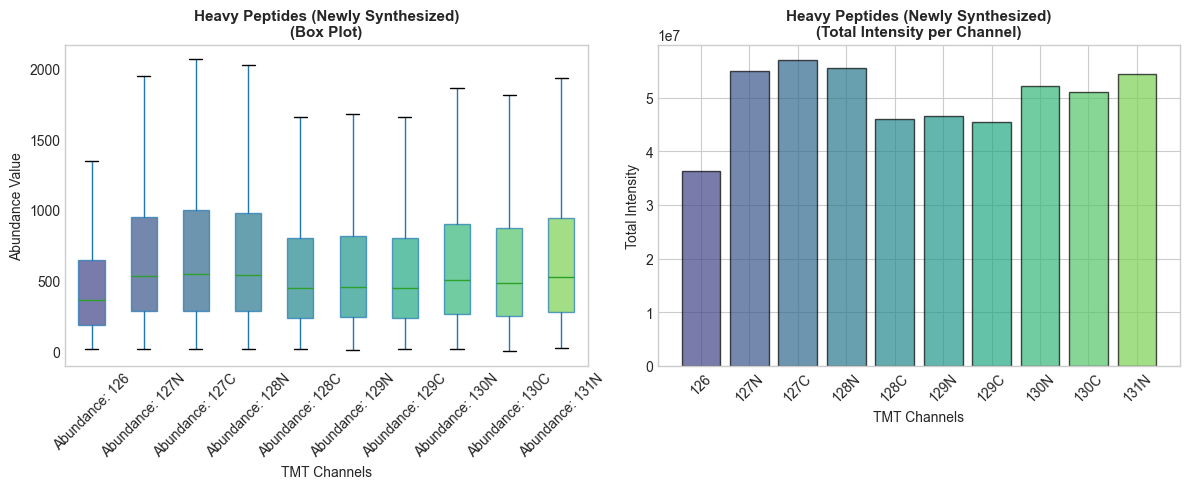


📈 Data Statistics for: Heavy Peptides (Newly Synthesized)
   └─ Rows: 65,547 | Columns: 47
   └─ Total Intensity Range: 36,258,118 - 57,041,092
   └─ CV between channels: 12.8%


,Abundance: 126,Abundance: 127N,Abundance: 127C,Abundance: 128N,Abundance: 128C,Abundance: 129N,Abundance: 129C,Abundance: 130N,Abundance: 130C,Abundance: 131N
1,227.671543,352.437412,249.845409,424.030892,396.511628,500.774756,487.626771,491.319143,196.528325,487.373815
6,158.796118,113.749641,118.452604,118.048689,112.790698,209.558002,136.995340,102.472521,187.889717,1061.510880
13,657.186346,677.835976,218.988008,568.522487,458.139535,505.693958,511.577005,462.041279,464.325163,476.662302
15,508.912861,383.205758,158.268606,351.312899,291.860465,373.859346,338.177309,263.500769,429.770732,318.131919
20,133.924437,91.372662,53.751602,164.323775,72.093023,53.127381,43.110422,53.981060,110.142248,87.834402
...,...,...,...,...,...,...,...,...,...,...
203361,226.659025,267.533924,268.308271,307.933642,328.593997,368.916830,393.592021,326.172973,534.010614,363.237031
203367,62.437962,96.990082,178.668204,198.406240,80.639423,136.458472,113.335169,171.689673,281.923112,124.535336
203368,43.047141,59.671943,41.806802,77.439940,68.604651,79.691071,27.782272,35.682396,53.991298,67.482528
203370,65.049012,70.860432,93.567603,67.996045,50.000000,87.561794,51.732506,82.343990,50.751820,79.265192


In [11]:
print_step_header(6, "HEAVY/LIGHT EXTRACTION", "🏷️")

# Extract heavy peptides (main analysis)
heavy = process.extract_heavy(normalized_data)

# Extract light peptides (optional - for old/degraded protein analysis)
light = process.extract_light(normalized_data)

# Summary
print(f"\n📊 Extraction Summary:")
print(f"   └─ Heavy PSMs: {heavy.shape[0]:,} ({heavy.shape[0]/normalized_data.shape[0]*100:.1f}%)")
print(f"   └─ Light PSMs: {light.shape[0]:,} ({light.shape[0]/normalized_data.shape[0]*100:.1f}%)")

# Visualize heavy peptides
plot_abundance_distribution(heavy, "Heavy Peptides (Newly Synthesized)")

---
## 🔧 Step 7: Baseline Correction / PSM to Peptide Conversion

**MS2 Workflow:** Apply baseline correction to remove noise, then convert to peptides
- Subtracts baseline channel from all samples
- Applies signal-to-noise threshold
- Converts PSMs to peptide level

**MS3 Workflow:** Direct conversion from PSMs to peptides (baseline already removed)


══════════════════════════════════════════════════════════════════════
🔧 STEP 7: BASELINE CORRECTION / PSM TO PEPTIDE
══════════════════════════════════════════════════════════════════════
🔹 MS2 Workflow: Applying baseline correction
   └─ Threshold: 15
   └─ Baseline index: 0
   └─ Random replacement: True
Calling function: baseline_correction
[#] Decision of this file is: PSMs
Calling function: PSMs_to_Peptide

✅ Baseline correction applied and PSMs converted to peptides

📊 Peptide Data Summary:
   └─ Peptides: 30,467
   └─ Columns: 13


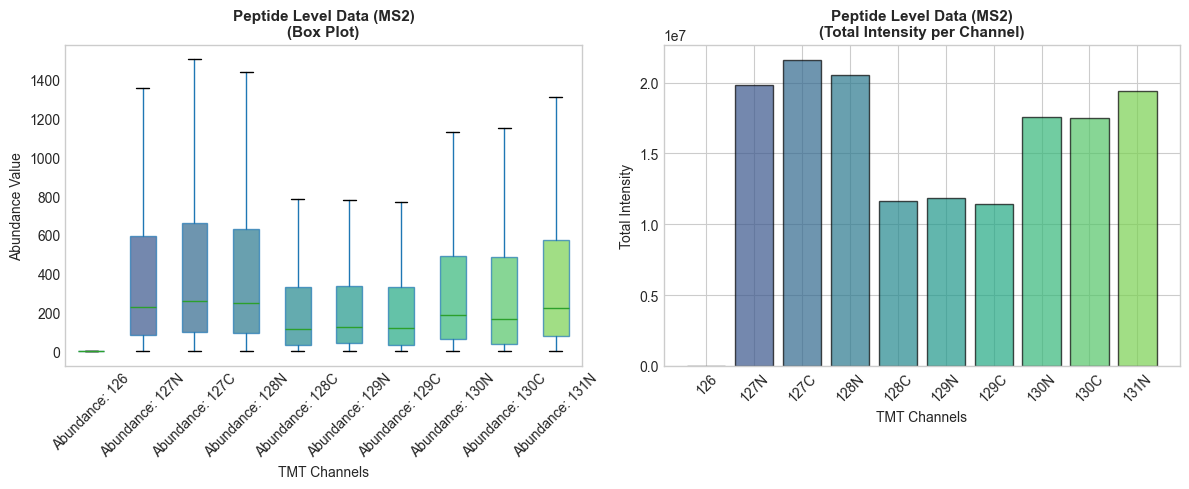


📈 Data Statistics for: Peptide Level Data (MS2)
   └─ Rows: 30,467 | Columns: 13
   └─ Total Intensity Range: 0 - 21,608,107
   └─ CV between channels: 43.4%


,Abundance: 126,Abundance: 127N,Abundance: 127C,Abundance: 128N,Abundance: 128C,Abundance: 129N,Abundance: 129C,Abundance: 130N,Abundance: 130C,Abundance: 131N
0,0.0,498.791309,413.933296,529.715890,212.195745,202.604392,164.301484,298.314038,255.012603,458.407710
1,0.0,121.937879,176.438655,229.790494,46.150269,87.909792,21.303932,186.751030,20.506231,118.060755
2,0.0,736.963624,791.711187,956.685031,377.791127,307.560751,376.184791,782.869505,800.560519,693.621517
3,0.0,296.192094,230.390144,334.480704,188.184034,204.877151,203.556855,281.518982,121.839217,286.112303
4,0.0,778.642216,948.255067,929.898642,0.799517,243.294289,313.006351,879.106789,535.724658,651.359737
...,...,...,...,...,...,...,...,...,...,...
30462,0.0,80.089810,74.273661,81.121406,34.890797,8.339730,0.909137,42.389589,14.092053,72.796366
30463,0.0,62.327519,114.723453,48.176407,84.841960,46.035755,102.370029,91.404098,116.113540,69.738631
30464,0.0,49.362940,51.844207,40.604030,0.577073,6.605459,27.368481,0.604575,27.170545,91.460776
30465,0.0,521.172142,987.787223,1358.812581,1220.736030,1510.421988,930.352310,1377.556524,2052.235963,498.349661


In [12]:
print_step_header(7, "BASELINE CORRECTION / PSM TO PEPTIDE", "🔧")

if WORKFLOW_TYPE == "MS2":
    print(f"🔹 MS2 Workflow: Applying baseline correction")
    print(f"   └─ Threshold: {BASELINE_THRESHOLD}")
    print(f"   └─ Baseline index: {BASELINE_INDEX}")
    print(f"   └─ Random replacement: {RANDOM_REPLACEMENT}")
    
    peptide_data = process.baseline_correction(
        heavy, 
        threshold=BASELINE_THRESHOLD, 
        i_baseline=BASELINE_INDEX, 
        random=RANDOM_REPLACEMENT
    )
    print(f"\n✅ Baseline correction applied and PSMs converted to peptides")
    
else:  # MS3
    print(f"🔹 MS3 Workflow: Direct PSM to Peptide conversion (no baseline correction)")
    peptide_data = process.PSMs_to_Peptide(heavy)
    print(f"\n✅ PSMs converted to peptides")

print(f"\n📊 Peptide Data Summary:")
print(f"   └─ Peptides: {peptide_data.shape[0]:,}")
print(f"   └─ Columns: {peptide_data.shape[1]}")

# Visualize peptide data
plot_abundance_distribution(peptide_data, f"Peptide Level Data ({WORKFLOW_TYPE})")

---
## 📈 Step 8: Statistical Analysis (PBLMM)

**Peptide-Based Linear Mixed Model (PBLMM)** performs statistical testing:
- Uses peptide-level data for robust statistics
- Accounts for protein as random effect
- Calculates fold changes and p-values for each comparison

In [13]:
%%time
print_step_header(8, "STATISTICAL ANALYSIS (PBLMM)", "📈")

print(f"🔹 Running Peptide-Based Linear Mixed Model...")
print(f"   └─ Conditions: {conditions}")
print(f"   └─ Comparisons: {pairs}")

# Run PBLMM analysis
hypothesis_testing = PBLMM.HypothesisTesting()
resultFinal = hypothesis_testing.peptide_based_lmm(
    peptide_data,
    conditions=conditions,
    pairs=pairs
)

# Clean up result
resultFinal.reset_index(inplace=True)
resultFinal.rename(columns={'index': 'Accession'}, inplace=True)

print(f"\n✅ Analysis completed!")
print(f"   └─ Proteins analyzed: {resultFinal.shape[0]:,}")
print(f"   └─ Output columns: {resultFinal.shape[1]}")

# Display preview
print(f"\n📋 Result Preview:")
display(resultFinal.head(10))


══════════════════════════════════════════════════════════════════════
📈 STEP 8: STATISTICAL ANALYSIS (PBLMM)
══════════════════════════════════════════════════════════════════════
🔹 Running Peptide-Based Linear Mixed Model...
   └─ Conditions: ['Light', 'DMSO', 'DMSO', 'DMSO', 'CCCP', 'CCCP', 'CCCP', 'CCCP_ISRIB', 'CCCP_ISRIB', 'CCCP_ISRIB']
   └─ Comparisons: [['CCCP', 'DMSO'], ['CCCP_ISRIB', 'DMSO'], ['CCCP_ISRIB', 'CCCP']]
Calculate Protein quantifications from Peptides
Combination done
Total Number of Datapoints:  304670
['CCCP', 'DMSO'] is analysing via PBLMM...
['CCCP_ISRIB', 'DMSO'] is analysing via PBLMM...
['CCCP_ISRIB', 'CCCP'] is analysing via PBLMM...

✅ Analysis completed!
   └─ Proteins analyzed: 5,060
   └─ Output columns: 20

📋 Result Preview:


,Accession,Light,DMSO,DMSO,DMSO,CCCP,CCCP,CCCP,CCCP_ISRIB,CCCP_ISRIB,CCCP_ISRIB,log2(CCCP/DMSO),p_value CCCP/DMSO,q_value CCCP/DMSO,log2(CCCP_ISRIB/DMSO),p_value CCCP_ISRIB/DMSO,q_value CCCP_ISRIB/DMSO,log2(CCCP_ISRIB/CCCP),p_value CCCP_ISRIB/CCCP,q_value CCCP_ISRIB/CCCP
0,A0A0B4J2D5,0.0,1698.296492,1559.121925,1428.664836,574.295830,170.122001,544.498474,309.707084,871.575699,836.699646,-4.102167,2.696330e-04,1.026200e-03,-2.585157,0.002276,0.023680,1.517010,2.089641e-01,4.126589e-01
1,A0A0B4J2F0,0.0,218.433200,270.333666,211.717017,12.310323,16.737720,29.807625,303.238109,129.160390,123.361164,-3.663734,5.812012e-21,2.832650e-19,-0.457189,0.294599,0.561053,3.206545,1.289298e-08,5.253628e-07
2,A0A2R8Y4L2,0.0,84.106081,134.003473,126.813097,95.006218,82.063789,76.268566,92.609467,370.883675,119.663743,-0.421728,6.856208e-02,1.134789e-01,0.507976,0.434836,0.675621,0.929704,1.349745e-01,3.157420e-01
3,A0A3B3IU46,0.0,168.094356,275.916860,330.315792,181.300740,134.979728,118.357996,134.898012,82.118432,263.577590,-0.801022,1.970733e-02,4.062268e-02,-0.797159,0.160426,0.414578,0.003863,9.940756e-01,9.977798e-01
4,A0AVT1,0.0,186.705640,320.673464,225.076761,186.383819,76.428390,54.298972,201.675108,69.168139,162.269392,-1.031916,4.054515e-01,4.865805e-01,-0.489664,0.682861,0.843870,0.542252,5.520268e-01,7.296907e-01
5,A0FGR8,0.0,7496.722172,8748.922161,8217.544380,4337.412867,4202.858087,4669.811140,6476.694551,5241.313281,6714.853249,-1.047578,8.735353e-04,2.847498e-03,-0.342346,0.252469,0.522523,0.705232,1.190308e-02,6.156682e-02
6,A0MZ66,0.0,302.210509,260.099416,199.858768,151.863544,206.304540,203.195572,310.077552,214.410983,278.044289,-2.074063,6.389277e-02,1.069496e-01,-1.046074,0.377277,0.633195,1.027989,4.569902e-01,6.555280e-01
7,A0PJW6,0.0,750.810523,1261.406876,989.240883,1529.042735,155.689293,251.367573,623.431117,444.410054,358.478040,-2.130009,4.807508e-02,8.444259e-02,-1.939651,0.077888,0.278167,0.190358,8.969364e-01,9.453433e-01
8,A1L0T0,0.0,3456.951351,3734.857875,3799.433283,1089.398806,1756.605408,1660.979639,3174.097157,2050.027098,4947.255627,-1.873962,1.710038e-03,5.109758e-03,-0.434944,0.460345,0.690518,1.439018,3.064587e-02,1.177892e-01
9,A1L188,0.0,100.510699,81.421310,123.168967,12.525285,0.800157,0.948020,114.254442,99.771834,93.036445,-5.564973,1.742032e-05,9.362958e-05,0.024452,0.899236,0.958870,5.589425,1.403875e-05,2.716687e-04


CPU times: total: 19min 4s
Wall time: 20min 59s


---
## 📊 Step 9: Results Visualization

Visualize the statistical results with volcano plots and summary statistics.


══════════════════════════════════════════════════════════════════════
📊 STEP 9: RESULTS VISUALIZATION
══════════════════════════════════════════════════════════════════════


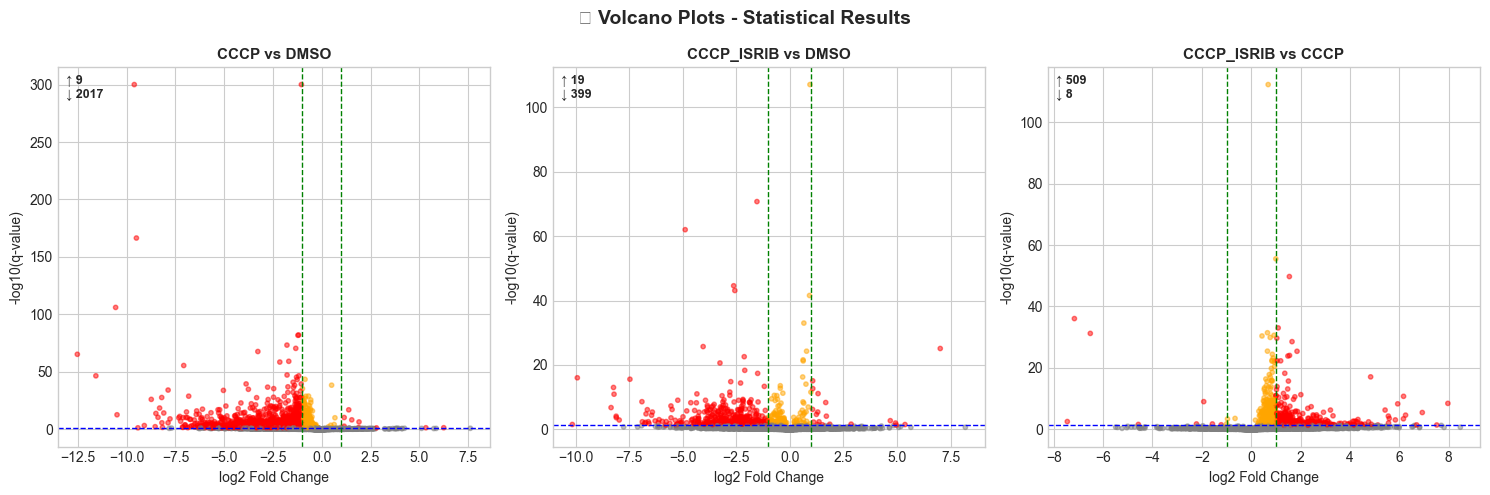


📊 Significance Summary (|log2FC| > 1, p < 0.05):
   └─ CCCP vs DMSO: 2026 significant proteins
   └─ CCCP_ISRIB vs DMSO: 418 significant proteins
   └─ CCCP_ISRIB vs CCCP: 517 significant proteins


In [14]:
print_step_header(9, "RESULTS VISUALIZATION", "📊")

# Create volcano plots for each comparison
n_pairs = len(pairs)
fig, axes = plt.subplots(1, n_pairs, figsize=(5*n_pairs, 5))
if n_pairs == 1:
    axes = [axes]

for idx, pair in enumerate(pairs):
    ax = axes[idx]
    
    # Get column names for this comparison using exact pattern matching
    comparison_pattern = f'{pair[0]}/{pair[1]}'
    fc_col = [c for c in resultFinal.columns if 'log2' in c and comparison_pattern in c]
    qval_col = [c for c in resultFinal.columns if 'q_value' in c.lower() and comparison_pattern in c]
    
    if fc_col and qval_col:
        fc_col = fc_col[0]
        qval_col = qval_col[0]
        
        # Calculate -log10(qvalue)
        log_qval = -np.log10(resultFinal[qval_col].replace(0, 1e-300))
        
        # Color based on significance
        colors = np.where(
            (np.abs(resultFinal[fc_col]) > 1) & (resultFinal[qval_col] < 0.05),
            'red',
            np.where(resultFinal[qval_col] < 0.05, 'orange', 'gray')
        )
        
        ax.scatter(resultFinal[fc_col], log_qval, c=colors, alpha=0.5, s=10)
        ax.axhline(y=-np.log10(0.05), color='blue', linestyle='--', linewidth=1, label='q=0.05')
        ax.axvline(x=-1, color='green', linestyle='--', linewidth=1)
        ax.axvline(x=1, color='green', linestyle='--', linewidth=1)
        
        ax.set_xlabel('log2 Fold Change', fontsize=10)
        ax.set_ylabel('-log10(q-value)', fontsize=10)
        ax.set_title(f'{pair[0]} vs {pair[1]}', fontsize=11, fontweight='bold')
        
        # Count significant
        sig_up = ((resultFinal[fc_col] > 1) & (resultFinal[qval_col] < 0.05)).sum()
        sig_down = ((resultFinal[fc_col] < -1) & (resultFinal[qval_col] < 0.05)).sum()
        ax.text(0.02, 0.98, f'↑ {sig_up}\n↓ {sig_down}', transform=ax.transAxes, 
                fontsize=9, verticalalignment='top', fontweight='bold')

plt.suptitle('🌋 Volcano Plots - Statistical Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary statistics
print("\n📊 Significance Summary (|log2FC| > 1, p < 0.05):")
for pair in pairs:
    comparison_pattern = f'{pair[0]}/{pair[1]}'
    fc_col = [c for c in resultFinal.columns if 'log2' in c and comparison_pattern in c]
    qval_col = [c for c in resultFinal.columns if 'q_value' in c.lower() and comparison_pattern in c]
    if fc_col and qval_col:
        fc_col, qval_col = fc_col[0], qval_col[0]
        sig = ((np.abs(resultFinal[fc_col]) > 1) & (resultFinal[qval_col] < 0.05)).sum()
        print(f"   └─ {pair[0]} vs {pair[1]}: {sig} significant proteins")

---
## 💾 Step 10: Export Results

Save the final results to Excel file with date stamp.

In [15]:
print_step_header(10, "EXPORT RESULTS", "💾")

# Generate output filename
output_filename = f"{nameOfStudy}_mePROD_PBLMM_{WORKFLOW_TYPE}_{date.today().strftime('%d.%m.%Y')}.xlsx"
output_path = f"{wd}/{output_filename}"

# Export to Excel
resultFinal.to_excel(output_path, index=False, engine='openpyxl')

print(f"✅ Results exported successfully!")
print(f"   └─ File: {output_filename}")
print(f"   └─ Path: {output_path}")
print(f"   └─ Proteins: {resultFinal.shape[0]:,}")
print(f"   └─ Columns: {resultFinal.shape[1]}")

print("\n" + "═"*70)
print("🎉 ANALYSIS COMPLETE!")
print("═"*70)


══════════════════════════════════════════════════════════════════════
💾 STEP 10: EXPORT RESULTS
══════════════════════════════════════════════════════════════════════
✅ Results exported successfully!
   └─ File: CCCP_ISRIB_Import_mePROD_PBLMM_MS2_18.03.2026.xlsx
   └─ Path: Example data/MS2_data/CCCP_ISRIB_Import_mePROD_PBLMM_MS2_18.03.2026.xlsx
   └─ Proteins: 5,060
   └─ Columns: 20

══════════════════════════════════════════════════════════════════════
🎉 ANALYSIS COMPLETE!
══════════════════════════════════════════════════════════════════════


---
## 🔄 Alternative: Protein Rollup (Without PBLMM)

If you prefer to use your own statistical analysis, use this section to:
1. Roll up peptides to protein level
2. Export protein-level data for external analysis


══════════════════════════════════════════════════════════════════════
🌙 STEP ALT-B: LIGHT PEPTIDE ANALYSIS
══════════════════════════════════════════════════════════════════════


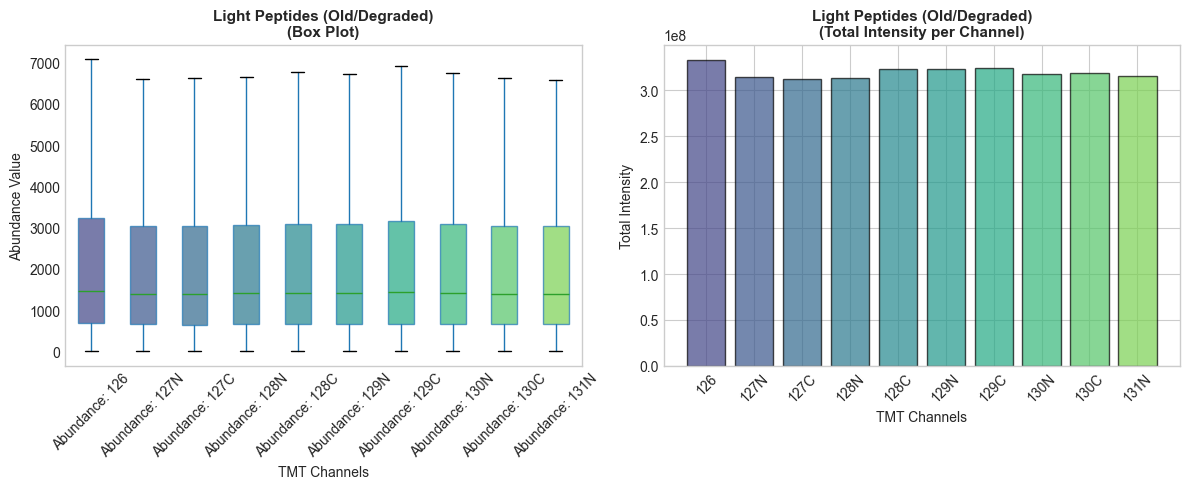


📈 Data Statistics for: Light Peptides (Old/Degraded)
   └─ Rows: 98,971 | Columns: 47
   └─ Total Intensity Range: 312,533,198 - 333,316,172
   └─ CV between channels: 2.0%
Calling function: PSMs_to_Peptide
✅ Light PSMs converted to peptides
   └─ Light Peptides: 48,330
Calling function: protein_rollup
✅ Light peptides rolled up to proteins using sum method
   └─ Light Proteins: 6,233


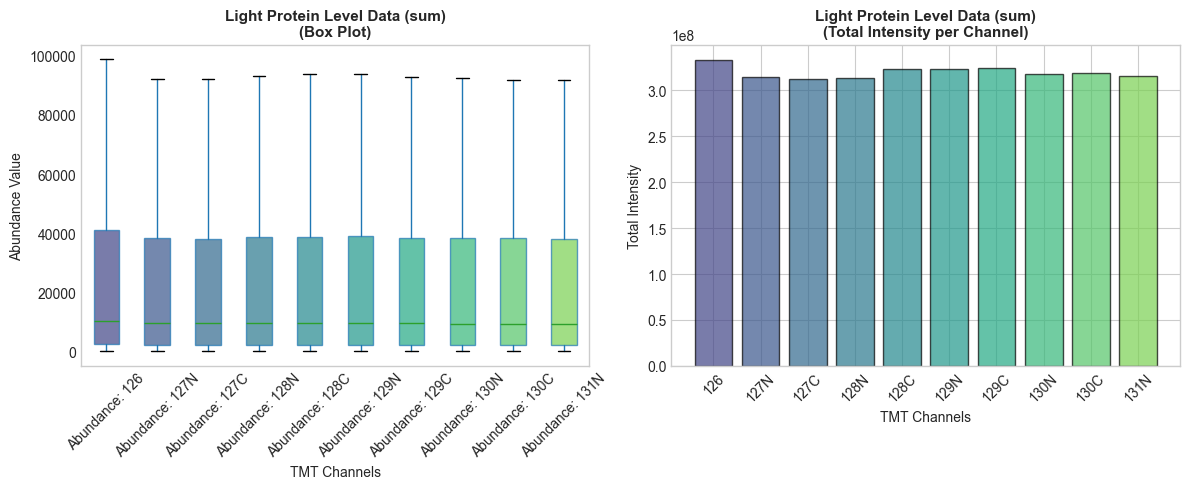


📈 Data Statistics for: Light Protein Level Data (sum)
   └─ Rows: 6,233 | Columns: 10
   └─ Total Intensity Range: 312,533,198 - 333,316,172
   └─ CV between channels: 2.0%

💾 Exported: CCCP_ISRIB_Import_Light_Proteins_sum_MS2_02.02.2026.xlsx


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║            OPTIONAL: Heavy Protein Rollup (Without PBLMM)                    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Uncomment and run this section if you want to do your own statistical analysis

# print_step_header("ALT-A", f"HEAVY PROTEIN ROLLUP ({ROLLUP_METHOD.upper()})", "🔄")

# heavy_protein_data = process.protein_rollup(peptide_data, method=ROLLUP_METHOD)

# print(f"✅ Heavy peptides rolled up to proteins using {ROLLUP_METHOD} method")
# print(f"   └─ Proteins: {heavy_protein_data.shape[0]:,}")

# # Visualize protein data
# plot_abundance_distribution(heavy_protein_data, f"Heavy Protein Level Data ({ROLLUP_METHOD})")

# # Export protein data
# heavy_protein_output = f"{nameOfStudy}_Heavy_Proteins_{ROLLUP_METHOD}_{WORKFLOW_TYPE}_{date.today().strftime('%d.%m.%Y')}.xlsx"
# heavy_protein_data.to_excel(f"{wd}/{heavy_protein_output}", engine='openpyxl')
# print(f"\n💾 Exported: {heavy_protein_output}")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║            OPTIONAL: Light Peptide Analysis (Old/Degraded Proteins)          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Uncomment and run this section to analyze light peptides (pre-existing proteins)

# print_step_header("ALT-B", "LIGHT PEPTIDE ANALYSIS", "🌙")

# # Visualize light peptides
# plot_abundance_distribution(light, "Light Peptides (Old/Degraded)")

# # Convert light PSMs to peptide level
# light_peptide_data = process.PSMs_to_Peptide(light)
# print(f"✅ Light PSMs converted to peptides")
# print(f"   └─ Light Peptides: {light_peptide_data.shape[0]:,}")

# # Roll up light peptides to protein level
# light_protein_data = process.protein_rollup(light_peptide_data, method=ROLLUP_METHOD)

# print(f"✅ Light peptides rolled up to proteins using {ROLLUP_METHOD} method")
# print(f"   └─ Light Proteins: {light_protein_data.shape[0]:,}")

# # Visualize light protein data
# plot_abundance_distribution(light_protein_data, f"Light Protein Level Data ({ROLLUP_METHOD})")

# # Export light protein data
# light_protein_output = f"{nameOfStudy}_Light_Proteins_{ROLLUP_METHOD}_{WORKFLOW_TYPE}_{date.today().strftime('%d.%m.%Y')}.xlsx"
# light_protein_data.to_excel(f"{wd}/{light_protein_output}", engine='openpyxl')
# print(f"\n💾 Exported: {light_protein_output}")